# **<center>Tutorial - Face Aligner</center>**

## Step 1: Load data and packages in your VM


In [ ]:
# import the necessary packages

import argparse
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import imutils

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
from IPython.display import clear_output

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
downloaded = drive.CreateFile({'id': '1ZrAPwcDKsgNe77D_Q5j7y5Egw_WKwpOg'})
downloaded.GetContentFile('folder.zip')        # replace the file name with your file
!unzip folder
clear_output()

In [ ]:
#@title Step 2: Install the RetinaFace package
!pip install retina-face
clear_output()

In [ ]:

from retinaface import RetinaFace # import the installed package

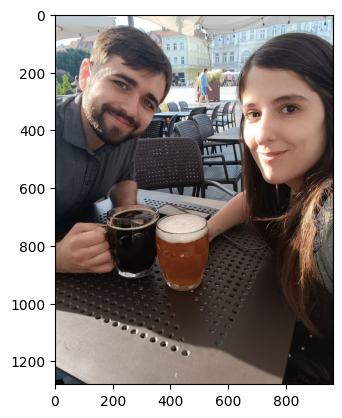

In [ ]:
#@title Step 2: Image display
# load the input image
image = cv2.imread('/content/prova.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# show the original input image
plt.imshow(image)
plt.show()




In [ ]:
#@title Step 3: RetinaFace Detector - deep learning based facial detector with facial landmarks


faces_aligned = RetinaFace.extract_faces(image, align = True)
faces_no_align = RetinaFace.extract_faces(image, align = False)



Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


25-02-19 15:56:47 - Directory /root/.deepface created
25-02-19 15:56:47 - Directory /root/.deepface/weights created
25-02-19 15:56:47 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:00<00:00, 365MB/s]


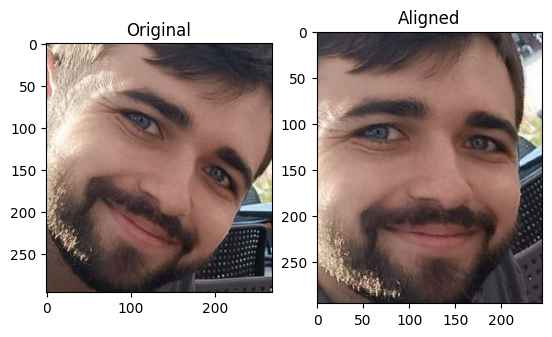

In [ ]:
#@title Step 4: Vizualize the original image and the aligned one.

fig, ax = plt.subplots(1, 2)
for i in range(len(faces_no_align)):
  face_aligned  = cv2.cvtColor(faces_aligned[i] , cv2.COLOR_BGR2RGB)
  face_no_align  = cv2.cvtColor(faces_no_align[i] , cv2.COLOR_BGR2RGB)
  face_aligned_resized = imutils.resize(face_aligned, width=256)
  face_aligned_no_align = imutils.resize(face_no_align, width=256)

  ax[0].imshow(face_no_align)
  ax[0].set_title("Original")
  ax[1].imshow(face_aligned)
  ax[1].set_title("Aligned")
  plt.show()

In [ ]:
#@title Step 5: Face detection usign RetinaFace

faces = RetinaFace.detect_faces(image)

In [ ]:
#@title This returns the facial area coordinates and some landmarks (eyes, nose and mouth) with a confidence score.
faces

{'face_1': {'score': 0.9993035793304443,
  'facial_area': [300, 92, 483, 347],
  'landmarks': {'right_eye': [331.58505, 179.86885],
   'left_eye': [404.41833, 196.97377],
   'nose': [332.75018, 221.70631],
   'mouth_right': [313.52933, 272.04758],
   'mouth_left': [372.96317, 286.38885]}}}

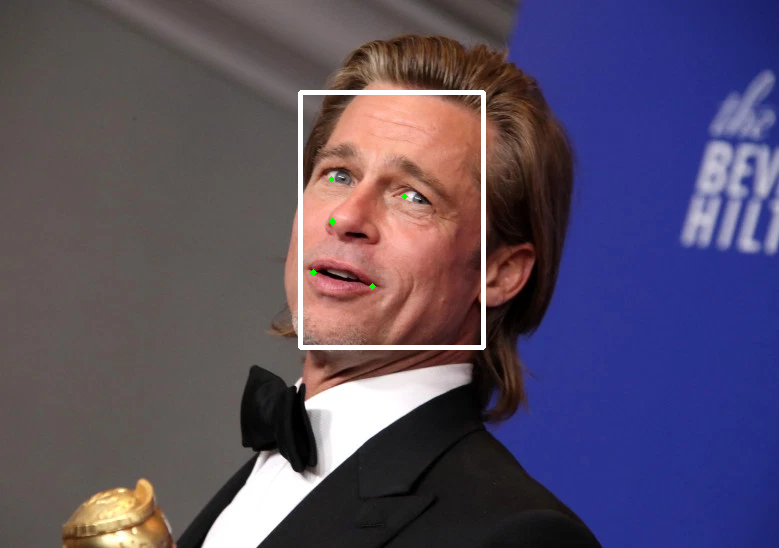

In [ ]:
#@title Step 6: Facial points visualization
for face in list(faces.keys()):
  id =faces[face]
  facial_area = id["facial_area"] #extract the facial landmarks
  landmarks = id["landmarks"] #extract the other landmarks
  img = image
  cv2.rectangle(img, (facial_area[2], facial_area[3]) #draw a rectangle delimiting the face area
   , (facial_area[0], facial_area[1]), (255, 255, 255), 3)

#highlight the landmarks drawing circles
cv2.circle(img, tuple([int(i) for i in landmarks["left_eye"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["right_eye"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["nose"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["mouth_left"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["mouth_right"]]), 1, (0, 255, 0), 3)
cv2_imshow(cv2.cvtColor(img , cv2.COLOR_BGR2RGB))

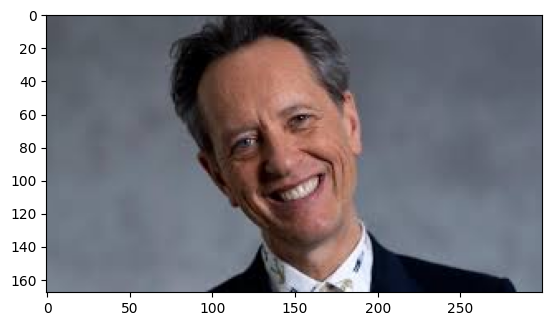

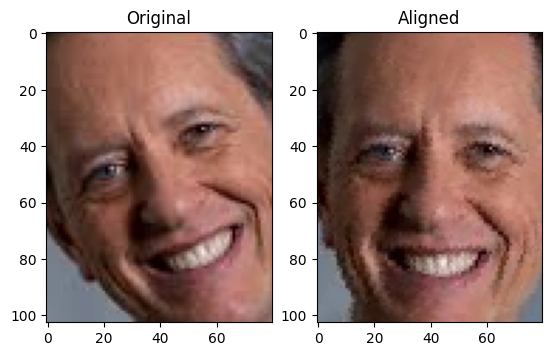

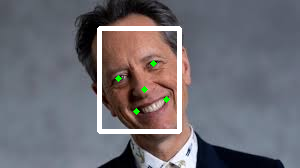

In [ ]:
#@title Another example

image = cv2.imread('/content/align/image_face.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# show the original input image
plt.imshow(image)
plt.show()

faces_aligned = RetinaFace.extract_faces(image, align = True)
faces_no_align = RetinaFace.extract_faces(image, align = False)

fig, ax = plt.subplots(1, 2)
for i in range(len(faces_no_align)):
  face_aligned  = cv2.cvtColor(faces_aligned[i] , cv2.COLOR_BGR2RGB)
  face_no_align  = cv2.cvtColor(faces_no_align[i] , cv2.COLOR_BGR2RGB)
  ax[0].imshow(face_no_align)
  ax[0].set_title("Original")
  ax[1].imshow(face_aligned)
  ax[1].set_title("Aligned")
  plt.show()

faces = RetinaFace.detect_faces(image)

for face in list(faces.keys()):
  id =faces[face]
  facial_area = id["facial_area"] #extract the facial landmarks
  landmarks = id["landmarks"] #extract the other landmarks
  img = image
  cv2.rectangle(img, (facial_area[2], facial_area[3]) #draw a rectangle delimiting the face area
   , (facial_area[0], facial_area[1]), (255, 255, 255), 3)

#highlight the landmarks drawing circles
cv2.circle(img, tuple([int(i) for i in landmarks["left_eye"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["right_eye"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["nose"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["mouth_left"]]), 1, (0, 255, 0), 3)
cv2.circle(img, tuple([int(i) for i in landmarks["mouth_right"]]), 1, (0, 255, 0), 3)
cv2_imshow(cv2.cvtColor(img , cv2.COLOR_BGR2RGB))